## Installing and importing the necessary libraries

In [79]:
# Installing the libraries with the specified version
!pip install --no-deps --force-reinstall tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 --no-deps --force-reinstall -q --user --no-warn-script-location

ERROR: Could not find a version that satisfies the requirement tensorflow==2.18.0 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0, 2.22.0rc0)
ERROR: No matching distribution found for tensorflow==2.18.0


In [80]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.

import time  # Module for time-related operations.

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense   # for creating fully connected neural network layers.

In [81]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it might affect the overall performance
tf.config.experimental.enable_op_determinism()

## Data Overview

In [82]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [83]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


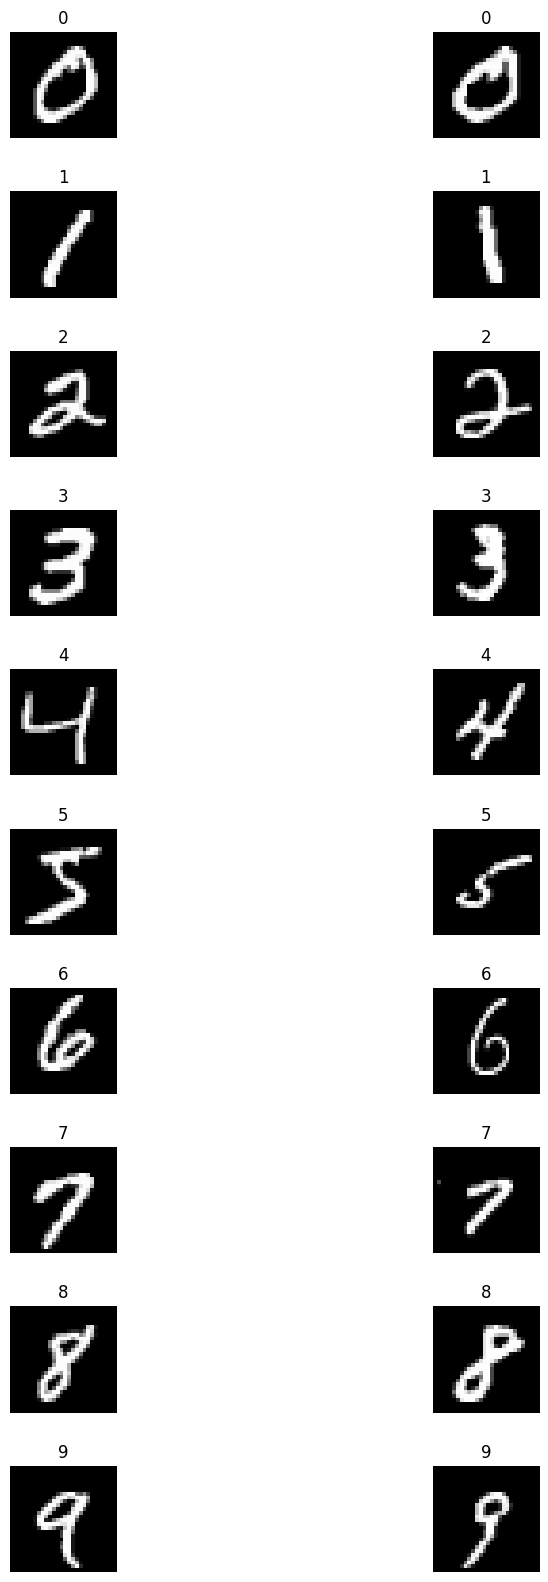

In [84]:
f, axarr = plt.subplots(10, 2, figsize=(10, 20))
for i in range(10):
    images = x_train[y_train == i]
    axarr[i, 0].imshow(images[0], cmap="gray")
    axarr[i, 1].imshow(images[1], cmap="gray")
    axarr[i, 0].axis("off")
    axarr[i, 1].axis("off")
    axarr[i, 0].set_title(str(i))
    axarr[i, 1].set_title(str(i))

plt.subplots_adjust(hspace=0.5)
plt.show()

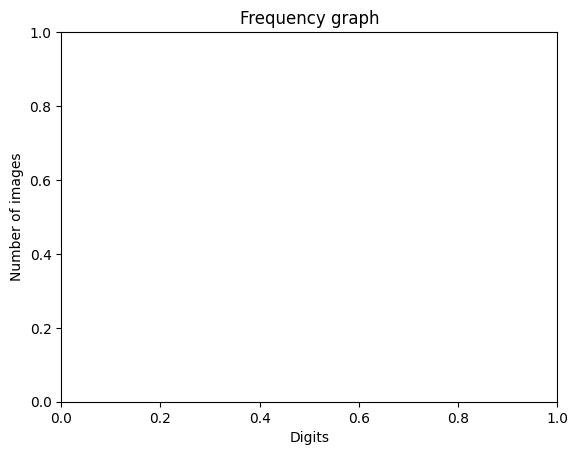

In [85]:
(pd.Series(y_train).value_counts())[[0, 1, 2, 3, 4, 5, 6, 7, 9, 8]]
plt.title("Frequency graph")
plt.xlabel("Digits")
plt.ylabel("Number of images")
plt.show()

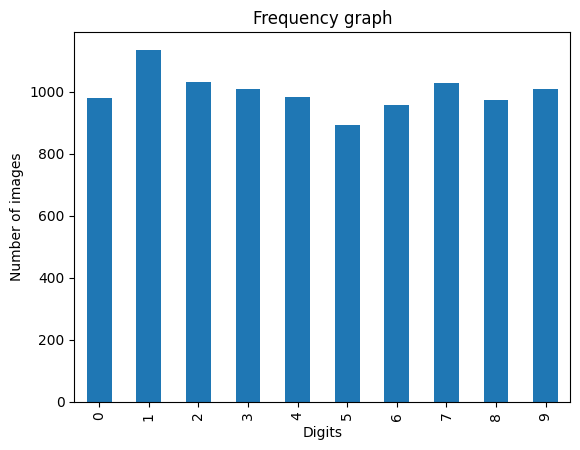

In [86]:
(pd.Series(y_test).value_counts())[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]].plot.bar()
plt.title("Frequency graph")
plt.xlabel("Digits")
plt.ylabel("Number of images")
plt.show()

In [87]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=1-(5/6), random_state=42,stratify=y_train)

In [88]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(50000, 28, 28)
(50000,)
(10000, 28, 28)
(10000,)


In [89]:
print(x_train.max(),x_test.max(),x_val.max())
print(x_train.min(),x_test.min(),x_val.min())

255 255 255
0 0 0


In [90]:
x_train, x_val, x_test = x_train.astype("float32")/(255), x_val.astype("float32")/(255), x_test.astype("float32")/(255)

In [91]:
print(x_train.max(),x_test.max(),x_val.max())
print(x_train.min(),x_test.min(),x_val.min())

1.0 1.0 1.0
0.0 0.0 0.0


In [92]:
x_train = x_train.reshape(x_train.shape[0],-1)
x_val = x_val.reshape(x_val.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)
print(x_train.shape[0], "train samples")
print(x_val.shape[0], "validation samples")
print(x_test.shape[0], "test samples")

50000 train samples
10000 validation samples
10000 test samples


In [93]:
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_train

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [94]:
def plot(history, name):
    fig, ax = plt.subplots()
    plt.plot(history.history[name])
    plt.plot(history.history["val_" + name])

    plt.title("Model " + name.capitalize())
    plt.ylabel(name.capitalize())
    plt.xlabel("Epoch")
    fig.legend(["Train", "Validation"], loc="outside right upper")

In [95]:
columns =[]

results = pd.DataFrame(columns=columns)

In [96]:
tf.keras.backend.clear_session()

In [97]:
model = Sequential()

model.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
x_train.shape[1]

784

In [99]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])


In [112]:
batch_size = x_train.shape[0]
epochs = 10

start = time.time()

history = model.fit(
    x_train, y_train,
    validation_data=(x_val,y_val),
    batch_size=batch_size,
    epochs=epochs
)


end = time.time()

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0848 - loss: 2.3601 - val_accuracy: 0.0859 - val_loss: 2.3556
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0861 - loss: 2.3541 - val_accuracy: 0.0876 - val_loss: 2.3500
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0872 - loss: 2.3484 - val_accuracy: 0.0884 - val_loss: 2.3446
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 787ms/step - accuracy: 0.0874 - loss: 2.3429 - val_accuracy: 0.0893 - val_loss: 2.3393
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step - accuracy: 0.0882 - loss: 2.3376 - val_accuracy: 0.0895 - val_loss: 2.3342
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step - accuracy: 0.0894 - loss: 2.3324 - val_accuracy: 0.0901 - val_loss: 2.3293
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step - accuracy: 0.0905 - loss: 2.3275 - val_accuracy: 0.0919 - val_loss: 2.3245
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step - accuracy: 0.0919 - loss: 2.3226 - val_accuracy: 0.0934 - val_loss: 2.3198
E

In [102]:
print("Time taken in seconds ",end-start)

Time taken in seconds  581.0948791503906


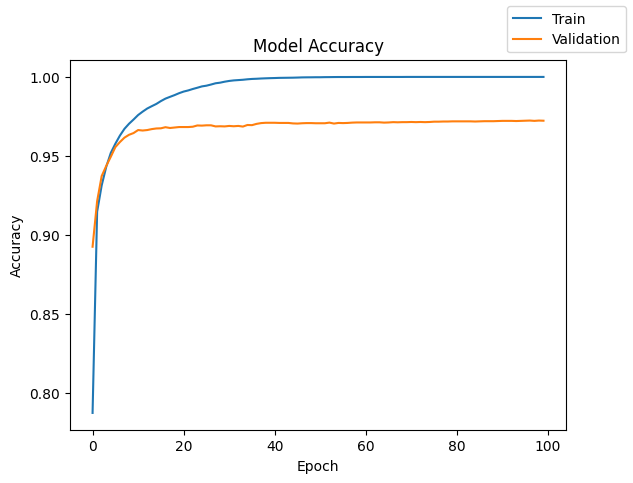

In [103]:
plot(history,'accuracy')

In [119]:
results.loc[0] = [0,'-','-',10,50000,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

ValueError: cannot set a frame with no defined columns

In [108]:
tf.keras.backend.clear_session()

In [109]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(num_classes, activation = 'softmax'))

In [110]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
batch_size = 32
epochs = 100
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [74]:
start = time.time()
history = model.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7875 - loss: 0.7364 - val_accuracy: 0.8926 - val_loss: 0.3645
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9147 - loss: 0.2935 - val_accuracy: 0.9214 - val_loss: 0.2720
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9314 - loss: 0.2332 - val_accuracy: 0.9373 - val_loss: 0.2298
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9432 - loss: 0.1955 - val_accuracy: 0.9437 - val_loss: 0.2020
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9519 - loss: 0.1679 - val_accuracy: 0.9495 - val_loss: 0.1807
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9577 - loss: 0.1465 - val_accuracy: 0.9556 - val_loss: 0.1649
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9629 - loss: 0.1295 - val_accuracy: 0.9588 - val_loss: 0.1530
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9672 - loss: 0

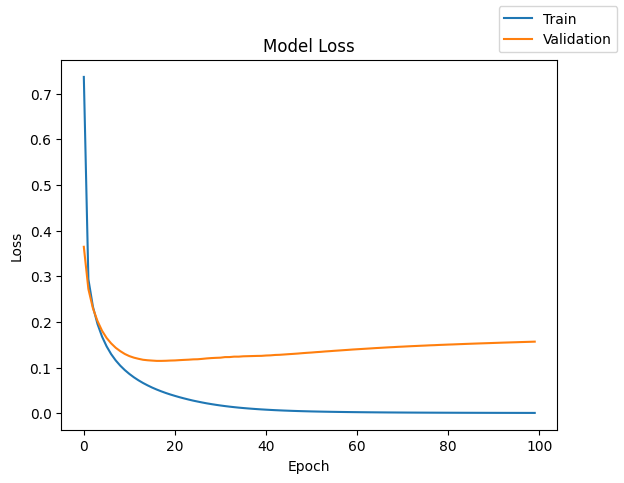

In [75]:
plot(history,'loss')

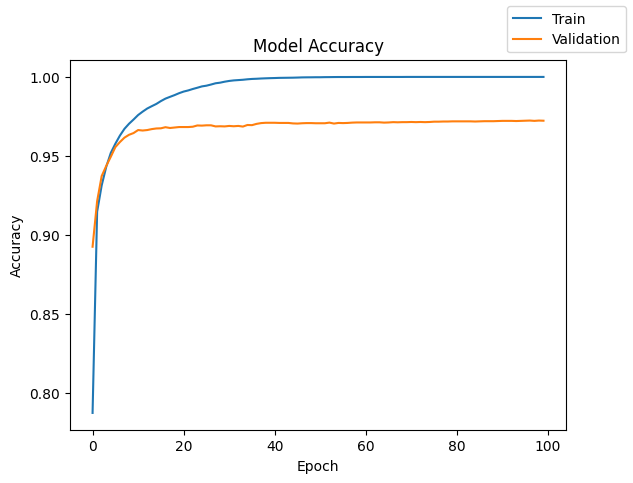

In [76]:
plot(history,'accuracy')

In [77]:
results.loc[13] = [3,[128,64,32],['relu','relu','relu'],100,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

In [78]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.1527,0.1628,15.00
13,3,"[128, 64, 32]","[relu, relu, relu]",100,32,0.000726,0.156780,1.0000,0.9723,581.09
